In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Load in the data
data_url = '../spambase_data/spambase.data'
names_url = '../spambase_data/spambase.names'

# parse the feature names from the .names file
feature_names = []
with open(names_url, "r") as f:
    for line in f:
        line = line.strip()
        if ':' in line and not line.startswith("|"):
            feature_names.append(line.split(":")[0].strip())
feature_names.append("label") # last column is the class label

df = pd.read_csv(data_url, header=None, names=feature_names)
x = df.drop("label", axis=1).values
y = df["label"].values

# Create the train test split for the data
x_tr, x_te, y_tr, y_te = train_test_split(
    x, y, test_size=0.25, random_state=42, stratify=y 
)

print(f"Train size: {x_tr.shape[0]}   |   Test size: {x_te.shape[0]}")
print(f"Spam prevalence - train: {y_tr.mean():.3f}  test: {y_te.mean():.3f}\n")

# Part 1 Train Random forest for T in {10, 50, 100, 500}
T_values = [10, 20, 100, 500] 
results = {}

print(f"{'='*65}")
print(f"    Part 1. - Random Forest Metrics by Number of Trees")
print(f"{'='*65}")
print(f"    {'T':<6} {'Split':<8} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print(f"    {'-'*46}")

for T in T_values:
    rf = RandomForestClassifier(n_estimators=T, random_state=42, n_jobs=1) 
    rf.fit(x_tr, y_tr)
    results[T] = {"Model": rf, "train" : {}, "test": {}}

    for split, Xs, ys in [("train", x_tr, y_tr), ("test", x_te, y_te)]:
        y_pred = rf.predict(Xs)
        y_prob = rf.predict_proba(Xs)[:, 1]
        acc = accuracy_score(ys, y_pred)
        f1 = f1_score(ys, y_pred)
        auc = roc_auc_score(ys, y_prob)
        results[T][split] = dict(accuracy=acc, f1=f1, auc=auc)
        print(f"    {T:<6} {split:<8} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}")
    print()  


Train size: 3450   |   Test size: 1151
Spam prevalence - train: 0.394  test: 0.394

    Part 1. - Random Forest Metrics by Number of Trees
    T      Split      Accuracy         F1        AUC
    ----------------------------------------------
    10     train        0.9971     0.9963     1.0000
    10     test         0.9418     0.9241     0.9772

    20     train        0.9991     0.9989     1.0000
    20     test         0.9470     0.9311     0.9831

    100    train        0.9997     0.9996     1.0000
    100    test         0.9513     0.9371     0.9860

    500    train        0.9997     0.9996     1.0000
    500    test         0.9513     0.9368     0.9864



# Observations for part 1 and 2
- Training metrics are near perfect across all T values 
- Test metrics improve as T increases drastically from T=10 to T=50 and has lesser metric increases at the next two T values
- Random forest outperforms every decision tree on all test metrics
- The auc improvemnt is significant at 0.9864 vs 0.9193  
- Random forest is still overfitting on training data with an AUC score of 1.00 but the test gap is much smaller than for single trees 
- unlike single decision trees, Random forest does not need explicit pruning tp generalize well  

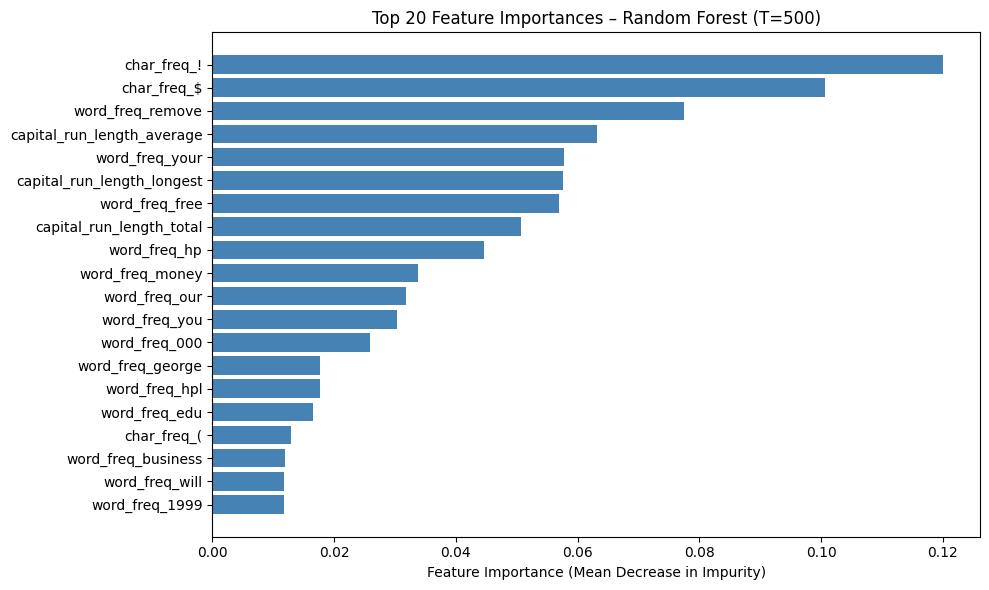


 Features by importance:
   1. char_freq_!                         0.1201
   2. char_freq_$                         0.1007
   3. word_freq_remove                    0.0774
   4. capital_run_length_average          0.0632
   5. word_freq_your                      0.0578
   6. capital_run_length_longest          0.0576
   7. word_freq_free                      0.0569
   8. capital_run_length_total            0.0508
   9. word_freq_hp                        0.0447
  10. word_freq_money                     0.0338
  11. word_freq_our                       0.0318
  12. word_freq_you                       0.0303
  13. word_freq_000                       0.0259
  14. word_freq_george                    0.0178
  15. word_freq_hpl                       0.0176
  16. word_freq_edu                       0.0165
  17. char_freq_(                         0.0130
  18. word_freq_business                  0.0119
  19. word_freq_will                      0.0118
  20. word_freq_1999                      0

In [13]:
# Part 3 feature importance
rf_best = results[500]["Model"]
importances = rf_best.feature_importances_

sorted_idx = np.argsort(importances)[::-1]
sorted_imp = importances[sorted_idx]
sorted_names = [feature_names[i] for i in sorted_idx]

# Plot top 20 features
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), sorted_imp[:top_n][::-1], color="steelblue")
plt.yticks(range(top_n), sorted_names[:top_n][::-1])
plt.xlabel("Feature Importance (Mean Decrease in Impurity)")
plt.title(f"Top {top_n} Feature Importances – Random Forest (T=500)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

print("\n Features by importance:")
for i in range(len(sorted_names)):
    print(f"  {i+1:>2}. {sorted_names[i]:<35} {sorted_imp[i]:.4f}")